<a href="https://colab.research.google.com/github/yas2218/Programming-in-Psych/blob/main/Copy_of_Python_week2_Spring2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Session 2

Now we are going to practice some analyses with our data

In [1]:
# Load in our choice and demographic data
import pandas as pd


data=pd.read_csv("https://raw.githubusercontent.com/CaitlinLloyd/Psychology_Programming2025/refs/heads/main/Data/demo.csv")
choices=pd.read_csv("https://raw.githubusercontent.com/CaitlinLloyd/Psychology_Programming2025/refs/heads/main/Data/FCT_df.csv")

In [3]:
choices

,Unnamed: 0,ID,block,trial_number,food,reaction_time,rating,fat,sugar
0,0,1,health,1,apple,2.68,7.0,high,low
1,1,1,health,2,beef,2.05,4.0,high,high
2,2,1,health,3,eggs,NaN,NaN,low,low
3,3,1,health,4,cookie,0.86,4.0,high,high
4,4,1,health,5,bacon,1.51,8.0,low,high
...,...,...,...,...,...,...,...,...,...
8995,8995,40,choice,71,toast,3.72,5.0,high,high
8996,8996,40,choice,72,pizza,0.95,8.0,high,low
8997,8997,40,choice,73,ice cream,3.36,6.0,high,low
8998,8998,40,choice,74,tofu,1.27,9.0,low,high


In [4]:
df_merged = pd.merge(data, choices, on='ID', how='left')


In [5]:
df_merged

,Unnamed: 0_x,ID,Age,Patient,Medication,BMI,Fat (g),Calories,Protein (g),Sugar (g),EDE Score,Duration of Illness,Unnamed: 0_y,block,trial_number,food,reaction_time,rating,fat,sugar
0,0,1,56,Yes,Yes,17.9,6,365,4,25,4.9,1.9,0,health,1,apple,2.68,7.0,high,low
1,0,1,56,Yes,Yes,17.9,6,365,4,25,4.9,1.9,1,health,2,beef,2.05,4.0,high,high
2,0,1,56,Yes,Yes,17.9,6,365,4,25,4.9,1.9,2,health,3,eggs,NaN,NaN,low,low
3,0,1,56,Yes,Yes,17.9,6,365,4,25,4.9,1.9,3,health,4,cookie,0.86,4.0,high,high
4,0,1,56,Yes,Yes,17.9,6,365,4,25,4.9,1.9,4,health,5,bacon,1.51,8.0,low,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,39,40,38,Yes,No,17.7,19,254,12,23,3.8,1.5,8995,choice,71,toast,3.72,5.0,high,high
8996,39,40,38,Yes,No,17.7,19,254,12,23,3.8,1.5,8996,choice,72,pizza,0.95,8.0,high,low
8997,39,40,38,Yes,No,17.7,19,254,12,23,3.8,1.5,8997,choice,73,ice cream,3.36,6.0,high,low
8998,39,40,38,Yes,No,17.7,19,254,12,23,3.8,1.5,8998,choice,74,tofu,1.27,9.0,low,high


In [6]:
# Now summarize the means and reaction times for foods varying in fat and sugar

#Now let's create a new dataframe and store each persons average RT and rating for high and low fat foods

# Group by participant, block, and fat level
summary_df = (
    df_merged
    .dropna(subset=['rating', 'reaction_time'])  # Exclude trials with missing values
    .groupby(['ID', 'block', 'fat','sugar'])
    .agg(
        average_rating=('rating', 'mean'),
        average_reaction_time=('reaction_time', 'mean'),
        trial_count=('rating', 'count')  # Optional: to see how many valid trials per group
    )
    .reset_index()
)

print(summary_df.head())

   ID   block   fat sugar  average_rating  average_reaction_time  trial_count
0   1  choice  high  high        5.333333               1.997333           15
1   1  choice  high   low        6.055556               2.148889           18
2   1  choice   low  high        5.576923               2.175769           26
3   1  choice   low   low        5.312500               2.511875           16
4   1  health  high  high        4.888889               1.976667           18


In [8]:
summary_df

,ID,block,fat,sugar,average_rating,average_reaction_time,trial_count
0,1,choice,high,high,5.333333,1.997333,15
1,1,choice,high,low,6.055556,2.148889,18
2,1,choice,low,high,5.576923,2.175769,26
3,1,choice,low,low,5.312500,2.511875,16
4,1,health,high,high,4.888889,1.976667,18
...,...,...,...,...,...,...,...
475,40,health,low,low,5.476190,2.473333,21
476,40,taste,high,high,5.444444,2.323333,18
477,40,taste,high,low,4.812500,2.063125,16
478,40,taste,low,high,5.066667,2.396000,15


In [10]:
# Pivot to wide format
df_wide  = summary_df.pivot_table(
    index='ID',
    columns=['block', 'fat','sugar'],
    values=['average_rating', 'average_reaction_time']
)


In [11]:
df_wide

average_rating                                                    \
block         choice                                  health             
fat             high                 low                high             
sugar           high       low      high       low      high       low   
ID                                                                       
1           5.333333  6.055556  5.576923  5.312500  4.888889  6.411765   
2           4.714286  6.352941  4.800000  5.050000  5.315789  4.125000   
3           5.421053  5.000000  6.050000  5.916667  4.222222  6.684211   
4           4.882353  4.461538  5.259259  6.312500  5.833333  5.352941   
5           5.444444  5.357143  5.421053  5.217391  6.142857  6.142857   
6           6.647059  6.400000  5.666667  4.750000  5.928571  5.190476   
7           6.647059  5.214286  6.285714  5.318182  5.000000  5.769231   
8           6.076923  6.294118  5.375000  5.684211  5.076923  5.500000   
9           6.444444  7.000000  4.333333  5.958333  5.409091  5.785714   
10          5.000000  4.473684  7.000000  6.357143  5.500000  5.684211   
11          4.800000  6.857143  5.062500  5.400000  5.444444  4.882353   
12          6.117647  5.611111  5.937500  6.863636  6.000000  6.333333   
13          5.937500  4.692308  6.105263  5.772727  5.846154  6.000000   
14          6.000000  5.434783  5.722222  5.666667  4.736842  4.555556   
15          5.875000  6.312500  5.650000  4.666667  6.529412  6.785714   
16          5.095238  6.071429  4.909091  4.941176  5.863636  7.083333   
17          4.666667  5.833333  5.235294  4.772727  5.826087  6.117647   
18          6.133333  5.611111  6.684211  5.590909  4.818182  4.869565   
19          5.461538  6.095238  4.761905  6.789474  6.444444  4.117647   
20          4.941176  5.166667  5.681818  5.478261  5.470588  5.750000   
21          5.444444  4.928571  4.700000  4.545455  5.615385  5.538462   
22          4.466667  6.000000  6.000000  5.833333  5.200000  4.933333   
23          5.333333  6.357143  6.285714  5.400000  5.650000  4.687500   
24          5.529412  7.200000  5.428571  5.050000  6.333333  5.266667   
25          5.611111  5.083333  5.461538  5.900000  4.600000  5.300000   
26          4.750000  4.714286  5.363636  6.833333  4.937500  5.466667   
27          5.454545  4.882353  6.000000  4.882353  6.529412  4.250000   
28          4.812500  4.909091  5.952381  5.923077  5.363636  5.050000   
29          5.733333  5.823529  5.944444  4.500000  4.631579  4.782609   
30          7.083333  5.850000  5.692308  5.466667  4.200000  5.958333   
31          5.470588  5.733333  6.173913  5.550000  5.375000  5.153846   
32          5.916667  4.764706  5.038462  5.000000  5.952381  5.375000   
33          5.727273  5.904762  5.560000  4.941176  5.615385  6.400000   
34          4.157895  5.809524  5.500000  5.571429  4.800000  5.636364   
35          6.444444  5.684211  4.857143  7.176471  5.294118  5.166667   
36          5.000000  5.866667  5.263158  5.695652  5.333333  5.500000   
37          5.000000  4.187500  6.333333  4.850000  5.214286  5.866667   
38          6.307692  4.437500  5.217391  5.772727  4.538462  5.500000   
39          4.857143  4.833333  6.083333  5.416667  4.714286  4.416667   
40          5.583333  5.631579  4.375000  5.576923  5.923077  5.047619   

                                               ... average_reaction_time  \
block                         taste            ...                choice   
fat         low                high            ...                   low   
sugar      high       low      high       low  ...                  high   
ID                                             ...                         
1      5.913043  5.066667  5.466667  5.066667  ...              2.175769   
2      5.913043  4.875000  5.388889  5.571429  ...              2.439000   
3      6.200000  5.600000  5.500000  4.863636  ...              2.476500   
4      6.750000  6.222222  5.869565  5.500000  ...              2.2

In [9]:
# Pivot to wide format
df_wide  = summary_df.pivot_table(
    index='ID',
    columns=['block', 'fat','sugar'],
    values=['average_rating', 'average_reaction_time']
)



# Flatten the column names
df_wide.columns = [
    f"{val}_{block}_fat{fat}_sugar{sugar}"
    for val, block, fat, sugar in df_wide.columns
]

df_wide = df_wide.reset_index()
print(df_wide.head())



   ID  average_rating_choice_fathigh_sugarhigh  \
0   1                                 5.333333   
1   2                                 4.714286   
2   3                                 5.421053   
3   4                                 4.882353   
4   5                                 5.444444   

   average_rating_choice_fathigh_sugarlow  \
0                                6.055556   
1                                6.352941   
2                                5.000000   
3                                4.461538   
4                                5.357143   

   average_rating_choice_fatlow_sugarhigh  \
0                                5.576923   
1                                4.800000   
2                                6.050000   
3                                5.259259   
4                                5.421053   

   average_rating_choice_fatlow_sugarlow  \
0                               5.312500   
1                               5.050000   
2                        

In [12]:
print(df_wide.head(20))

      average_rating                                                    \
block         choice                                  health             
fat             high                 low                high             
sugar           high       low      high       low      high       low   
ID                                                                       
1           5.333333  6.055556  5.576923  5.312500  4.888889  6.411765   
2           4.714286  6.352941  4.800000  5.050000  5.315789  4.125000   
3           5.421053  5.000000  6.050000  5.916667  4.222222  6.684211   
4           4.882353  4.461538  5.259259  6.312500  5.833333  5.352941   
5           5.444444  5.357143  5.421053  5.217391  6.142857  6.142857   
6           6.647059  6.400000  5.666667  4.750000  5.928571  5.190476   
7           6.647059  5.214286  6.285714  5.318182  5.000000  5.769231   
8           6.076923  6.294118  5.375000  5.684211  5.076923  5.500000   
9           6.444444  7.000000  4.3333

In [13]:
# now select some columns from the demographic frame and merge with our wide_df
demo_sub=data[['ID','Patient','BMI','EDE Score','Age']]


In [37]:
demo_sub=pd.merge(demo_sub,df_wide,on='ID',how='left')

MergeError: Not allowed to merge between different levels. (1 levels on the left, 4 on the right)

In [ ]:
# Rename 'Fat (g)' column to 'Fat_g' for easier access
data = data.rename(columns={'Fat (g)': 'Fat_g'})

In [ ]:
vars_of_interest=['Fat_g','Age']

grouped_corrs = data.groupby('Patient')[vars_of_interest].corr()

print("Correlation for Patients (Yes):")
print(grouped_corrs.loc['Yes'])

print("\nCorrelation for Controls (No):")
print(grouped_corrs.loc['No'])

In [27]:
demo_sub

,ID,Patient,BMI,EDE Score,Age
0,1,Yes,17.9,4.9,56
1,2,Yes,18.6,5.3,46
2,3,No,22.3,0.6,32
3,4,No,22.9,0.5,60
4,5,Yes,15.7,4.1,25
5,6,Yes,17.2,3.5,38
6,7,Yes,18.7,4.6,56
7,8,Yes,17.2,4.2,36
8,9,No,22.0,1.7,40
9,10,No,22.8,0.2,28


In [18]:
# now let's group by patient group and calculate means of food ratings, BMI, age, EDEQ
# we first need to import numpy
demo_sub.groupby(['Patient']).agg(
average_rating=('BMI', 'mean'))


,average_rating
Patient,
No,23.510526
Yes,17.304762


In [23]:
# mean is np.mean()
import numpy as np
np.mean(demo_sub.BMI)

np.float64(20.252499999999998)

In [19]:
import pandas as pd
from scipy.stats import ttest_ind

In [20]:
# now lets compare the groups using a t-test
vars_to_test=['BMI','Age']
# Split the data by group
patients = demo_sub[demo_sub['Patient'] == 'Yes']
controls = demo_sub[demo_sub['Patient'] == 'No']

# Store results
results = []

for var in vars_to_test:
    # Run t-test
    t_stat, p_val = ttest_ind(patients[var], controls[var], equal_var=False)  # Welch's t-test

    results.append({
        'variable': var,
        'mean_patient': patients[var].mean(),
        'mean_control': controls[var].mean(),
        't_stat': t_stat,
        'p_value': p_val
    })

# Convert to DataFrame
ttest_results = pd.DataFrame(results)
print(ttest_results)

  variable  mean_patient  mean_control     t_stat       p_value
0      BMI     17.304762     23.510526 -10.791807  1.388539e-11
1      Age     43.857143     39.473684   1.039726  3.050922e-01


What do these data tell us?

In [ ]:
# Now let's average across the high and low sugar foods for each person - we need to create a new variable

In [21]:
# Now do some plots to show associations between two variables
import matplotlib.pyplot as plt
import seaborn as sns



In [39]:
# color by patient group
plt.figure(figsize=(8, 6))
sns.lmplot(data=demo_sub, x='BMI', y='average_rating_choice_fathigh_sugarhigh', hue='Patient',line_kws={'linewidth': 2})
plt.title('BMI vs. Average High-Fat Food Rating')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('High-Fat Food Rating (1–10)')
plt.grid(True)
plt.tight_layout()
plt.show()

KeyError: "['average_rating_choice_fathigh_sugarhigh'] not in index"

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

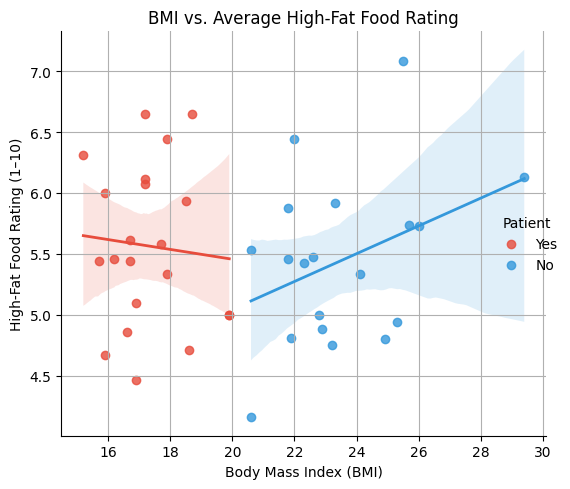

In [ ]:
#We can change the colors using a custom palette

custom_palette = {
    'Yes': '#E74C3C',   # red
    'No': '#3498DB'    # blue
}

# color by patient group
plt.figure(figsize=(8, 6))
sns.lmplot(data=demo_sub, x='BMI', y='average_rating_choice_fathigh_sugarhigh', hue='Patient',line_kws={'linewidth': 2},palette=custom_palette)
plt.title('BMI vs. Average High-Fat Food Rating')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('High-Fat Food Rating (1–10)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# change the plot labels

In [ ]:
#Is the plot different if we look at high-fat and low-sugar foods?
# How about if we plot average high-fat (collapse across sugar)

In [ ]:
# Advanced
# Try and plot, in the patient group only BMI against choice preference for high vs low fat

In [ ]:
# Let's also look at age

In [40]:
# Now, let's use a regression model to compare patients and HC and adjust for age
import statsmodels.formula.api as smf

# Variables to test
variables = ['BMI']

results = []

for var in variables:
    # Formula: outcome ~ patient_status + age
    formula = f"{var} ~ C(Patient) + Age"

    # Fit linear model
    model = smf.ols(formula=formula, data=demo_sub).fit()

    # Extract results for patient_status (the group effect)
    coef = model.params.get('C(Patient)[T.Yes]', float('nan'))
    pval = model.pvalues.get('C(Patient)[T.Yes]', float('nan'))
    conf_int = model.conf_int().loc['C(Patient)[T.Yes]'].tolist()

    results.append({
        'variable': var,
        'coef_patient_vs_control': coef,
        'p_value': pval,
        'conf_lower': conf_int[0],
        'conf_upper': conf_int[1]
    })

# Convert to DataFrame and print
df_results = pd.DataFrame(results)
print(df_results)

  variable  coef_patient_vs_control       p_value  conf_lower  conf_upper
0      BMI                -6.148525  6.697756e-13    -7.31085     -4.9862


In [ ]:
demo_sub

,ID,Patient,BMI,EDE Score,Age,average_rating_choice_fathigh_sugarhigh,average_rating_choice_fathigh_sugarlow,average_rating_choice_fatlow_sugarhigh,average_rating_choice_fatlow_sugarlow,average_rating_health_fathigh_sugarhigh,...,average_reaction_time_choice_fatlow_sugarhigh,average_reaction_time_choice_fatlow_sugarlow,average_reaction_time_health_fathigh_sugarhigh,average_reaction_time_health_fathigh_sugarlow,average_reaction_time_health_fatlow_sugarhigh,average_reaction_time_health_fatlow_sugarlow,average_reaction_time_taste_fathigh_sugarhigh,average_reaction_time_taste_fathigh_sugarlow,average_reaction_time_taste_fatlow_sugarhigh,average_reaction_time_taste_fatlow_sugarlow
0,1,Yes,17.9,4.9,56,5.333333,6.055556,5.576923,5.312500,4.888889,...,2.175769,2.511875,1.976667,1.978235,1.944348,2.838667,2.131333,2.360667,2.097000,2.208000
1,2,Yes,18.6,5.3,46,4.714286,6.352941,4.800000,5.050000,5.315789,...,2.439000,2.123000,2.256316,2.758750,2.086522,2.295833,2.171111,2.287143,2.273500,2.128182
2,3,No,22.3,0.6,32,5.421053,5.000000,6.050000,5.916667,4.222222,...,2.476500,2.435417,1.810000,2.247368,2.176000,2.136400,2.181875,2.464545,2.211579,2.096667
3,4,No,22.9,0.5,60,4.882353,4.461538,5.259259,6.312500,5.833333,...,2.267037,2.182500,2.307778,2.170588,2.108500,2.018333,2.093043,2.081000,1.867000,2.108500
4,5,Yes,15.7,4.1,25,5.444444,5.357143,5.421053,5.217391,6.142857,...,2.062632,2.337826,2.427857,2.234286,2.555833,2.189130,2.252667,1.963636,2.265455,2.099630
5,6,Yes,17.2,3.5,38,6.647059,6.400000,5.666667,4.750000,5.928571,...,2.444444,2.656250,2.175000,2.060000,2.025000,2.566500,2.400952,2.225000,2.108000,2.526316
6,7,Yes,18.7,4.6,56,6.647059,5.214286,6.285714,5.318182,5.000000,...,1.920952,2.303636,2.341000,2.266923,2.211304,2.291053,2.748889,2.758667,2.316522,1.485882
7,8,Yes,17.2,4.2,36,6.076923,6.294118,5.375000,5.684211,5.076923,...,2.215833,2.490526,2.083846,2.222500,1.908333,2.111429,2.855625,2.147500,2.400000,1.908421
8,9,No,22.0,1.7,40,6.444444,7.000000,4.333333,5.958333,5.409091,...,1.991250,2.411667,2.359091,2.022857,1.825652,2.031333,2.254286,2.166154,2.113333,2.449565
9,10,No,22.8,0.2,28,5.000000,4.473684,7.000000,6.357143,5.500000,...,2.410588,2.347143,2.125000,2.693158,2.651176,2.317692,2.486842,2.321739,2.087917,2.232222


In [41]:
# We can create interaction terms by using * (e.g., Patient * fat would be an interaction between Patient and fat content)
# Try now to examine whether patients and HC differ in choice ratings for high and low fat foods

demo_sub['high_fat_choice'] = demo_sub.average_rating_choice_fathigh_sugarhigh + demo_sub.average_rating_choice_fathigh_sugarlow
demo_sub['low_fat_choice'] = demo_sub.average_rating_choice_fathigh_sugarhigh + demo_sub.average_rating_choice_fathigh_sugarlow

long_vars=demo_sub[['ID','high_fat_choice','low_fat_choice','Patient','Age','BMI']]


long = pd.melt(long_vars,
                  id_vars=['ID'],
                  value_vars=['high_fat_choice','low_fat_choice'],
                  var_name='Fat',
                  value_name='Choice')

long=pd.merge(long,long_vars)




AttributeError: 'DataFrame' object has no attribute 'average_rating_choice_fathigh_sugarhigh'

In [42]:
formula = "Choice ~ C(Patient)*Fat + Age"


model = smf.mixedlm(formula=formula, data=long,groups="ID").fit()

# Extract results for patient_status (the group effect)
coef = model.params.get('C(Patient)[T.Yes]', float('nan'))
pval = model.pvalues.get('C(Patient)[T.Yes]', float('nan'))
conf_int = model.conf_int().loc['C(Patient)[T.Yes]'].tolist()

NameError: name 'long' is not defined

In [ ]:
# Is this significant?

In [ ]:
# Now try to group the demo df by patient status and correlate fat intake at meal and age

In [ ]:
data

,Unnamed: 0,ID,Age,Patient,Medication,BMI,Fat (g),Calories,Protein (g),Sugar (g),EDE Score,Duration of Illness
0,0,1,56,Yes,Yes,17.9,6,365,4,25,4.9,1.9
1,1,2,46,Yes,Yes,18.6,9,306,12,15,5.3,1.5
2,2,3,32,No,Yes,22.3,24,635,36,20,0.6,NaN
3,3,4,60,No,No,22.9,32,456,27,21,0.5,NaN
4,4,5,25,Yes,No,15.7,11,332,16,17,4.1,9.6
5,5,6,38,Yes,No,17.2,12,318,9,14,3.5,8.6
6,6,7,56,Yes,No,18.7,14,213,8,16,4.6,4.2
7,7,8,36,Yes,No,17.2,14,317,10,18,4.2,9.6
8,8,9,40,No,No,22.0,25,784,23,24,1.7,NaN
9,9,10,28,No,No,22.8,19,576,22,29,0.2,NaN


In [ ]:
vars_of_interest=['BMI','Calories']

grouped_corrs = data.groupby('Patient')[vars_of_interest].corr()



# To access individual group's correlation matrix:
corr_patient = grouped_corrs.loc['Yes']
corr_control = grouped_corrs.loc['No']

## Homework
Complete the tasks below and upload solution to Github

In [ ]:
## Calculate the average number of delayed choices in patient and HC groups



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dd_data = pd.read_csv("https://raw.githubusercontent.com/CaitlinLloyd/Psychology_Programming2025/refs/heads/main/Data/DD_df.csv")

avg_choices = dd_data.groupby(['group', 'condition'])['chose_delayed'].mean().reset_index()
print("Average proportion of delayed choices:")
print(avg_choices)

Average proportion of delayed choices:
     group condition  chose_delayed
0      SUD   control         0.2472
1      SUD    future         0.6668
2  control   control         0.4992
3  control    future         0.7128


In [ ]:
## Correlation between delayed choices and impulsivity scale per group

In [8]:
per_person_df = dd_data.groupby(['participant_id', 'group', 'impulsivity'])['chose_delayed'].sum().reset_index()
per_person_df.rename(columns={'chose_delayed': 'total_delayed_choices'}, inplace=True)

group_corrs = per_person_df.groupby('group')[['impulsivity', 'total_delayed_choices']].corr()

print("\nCorrelation between Impulsivity and Total Delayed Choices by Group:")
print(group_corrs)


Correlation between Impulsivity and Total Delayed Choices by Group:
                               impulsivity  total_delayed_choices
group                                                            
SUD     impulsivity               1.000000              -0.885279
        total_delayed_choices    -0.885279               1.000000
control impulsivity               1.000000              -0.815053
        total_delayed_choices    -0.815053               1.000000


In [ ]:
## Plot delayed choices and impulsivity by patient group

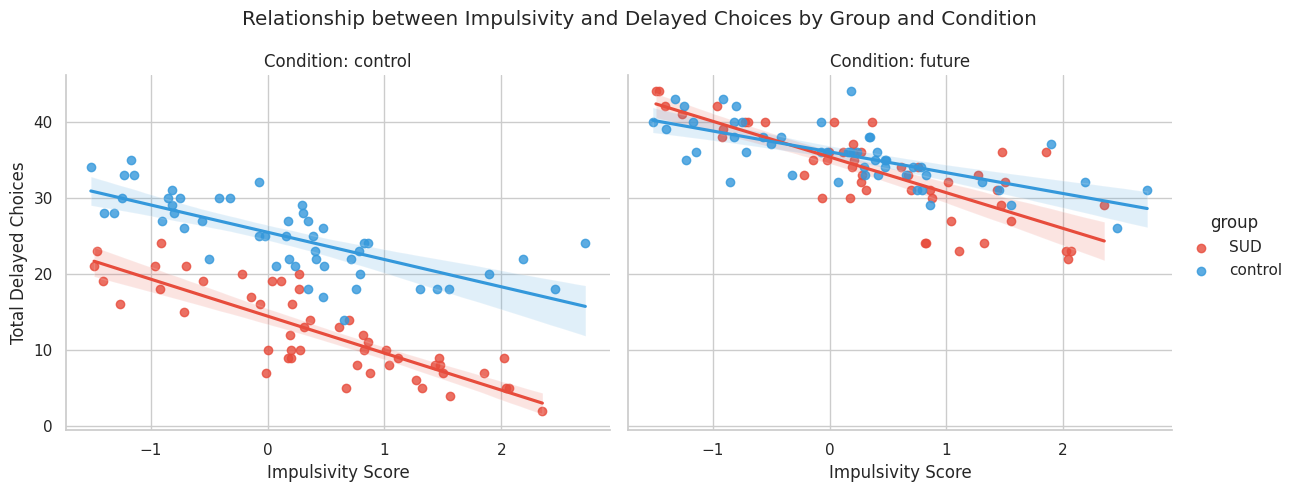

In [12]:
plot_data = dd_data.groupby(['participant_id', 'group', 'condition', 'impulsivity'])['chose_delayed'].sum().reset_index()

sns.set_theme(style="whitegrid")
g = sns.lmplot(
    data=plot_data,
    x='impulsivity',
    y='chose_delayed',
    hue='group',
    col='condition',
    palette={'SUD': '#E74C3C', 'control': '#3498DB'},
    height=5,
    aspect=1.2
)

g.set_axis_labels("Impulsivity Score", "Total Delayed Choices")
g.set_titles("Condition: {col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Relationship between Impulsivity and Delayed Choices by Group and Condition')

plt.show()
